In [1]:
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import pandas as pd
base_casas = pd.read_csv('../13-Regressao/house_prices.csv')
base_casas.tail()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287
21612,1523300157,20141015T000000,325000.0,2,0.75,1020,1076,2.0,0,0,...,7,1020,0,2008,0,98144,47.5941,-122.299,1020,1357


In [4]:
base_casas.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [5]:
# data da publicação do preço (date)
# price - preço
# sqft_living - metragem quadrada do local, casa apt. (sua atualização - sqft_living15)
# sqft_lot - metragem quadrada do lote.  (sua atualização - sqft_lot15)
# floors - quantidade dos andares.
# condition- condição da casa.
# grade - nota da casa.
# yr_built - ano construida.
# yr_renovated - ano renovada.
# zipcode - cep.


In [6]:
base_casas.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


Primeiro quartil 25% da base de dados.

Terceiro Quartil 75% da base de dados.

Segundo Quartil 50% da base de dados. -> ou a mediana.

mean - média







Verificar atributos faltantes

In [7]:
base_casas_copy= base_casas.copy()

In [8]:
# ATUALIZAÇÃO OUT-2024: a versão atual do Pandas não está considerando o formato do dado como data, vamos remover esta coluna
base_casas.drop('date', axis=1, inplace=True)

In [9]:
base_casas.isnull().tail()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
21608,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
21609,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
21610,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
21611,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
21612,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
base_casas.isnull().sum()

id               0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

Verificar a correlação

In [11]:
base_casas.corr()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,1.000000,-0.016762,0.001286,0.005160,-0.012258,-0.132109,0.018525,-0.002721,0.011592,-0.023783,0.008130,-0.010842,-0.005151,0.021380,-0.016907,-0.008224,-0.001891,0.020799,-0.002901,-0.138798
price,-0.016762,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,0.001286,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
bathrooms,0.005160,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
sqft_living,-0.012258,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,-0.132109,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,0.018525,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,-0.002721,0.266369,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.011592,0.397293,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,-0.023783,0.036362,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406


<Axes: >

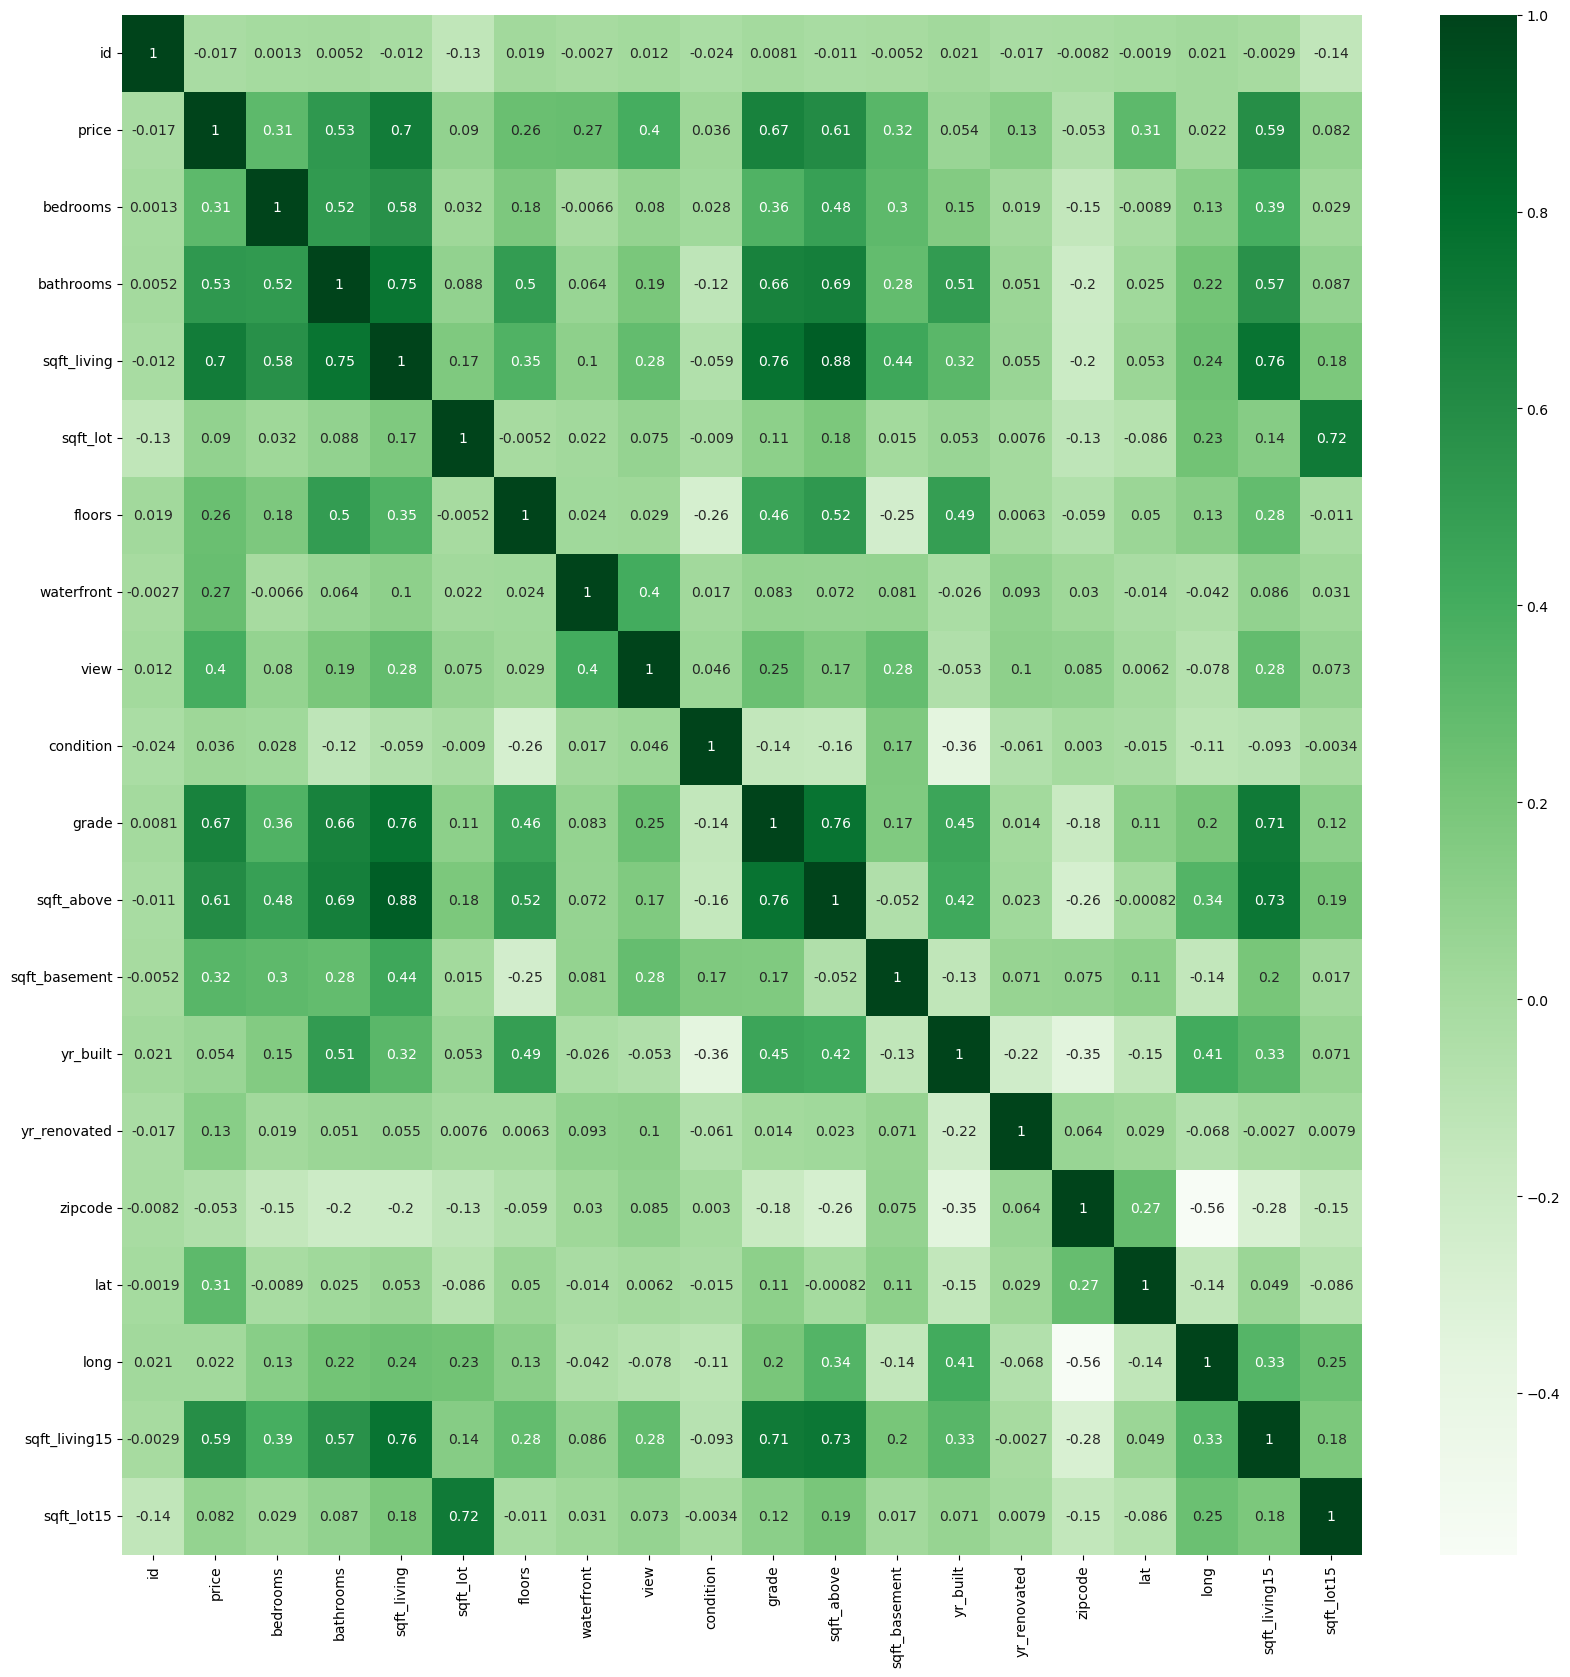

In [21]:
figura = plt.figure(figsize=(20,20))
#sns.heatmap(base_casas.corr(), annot=True, cmap= 'green');  # annot -> colocar os valores

sns.heatmap(base_casas.corr(numeric_only=True), annot=True, cmap='Greens')


In [14]:
# criaremos as variáveis

#buscar somente a coluna 5

In [15]:
X_casas = base_casas_copy.iloc[:,5:6].values   #coluna de interesse: sqft_living, metragem da casa que é o nosso previsor.
X_casas

array([[1180],
       [2570],
       [ 770],
       ...,
       [1020],
       [1600],
       [1020]])

In [16]:
y_casas = base_casas_copy.iloc[:, 2].values  # valor da casa, ou price
y_casas

array([221900., 538000., 180000., ..., 402101., 400000., 325000.])

In [17]:
# vamos prever os preços, para isso vamos separar bases dos treinos.

from sklearn.model_selection import train_test_split
X_casas_treinamento, X_casas_teste, y_casas_treinamento, y_casas_teste = train_test_split(X_casas, y_casas, test_size = 0.3, random_state = 0)

In [18]:
# 30% para testar, e os 70% para treinar.
# test_size = 0.3
# random_state=0, mesma divisão com os mesmos registros

X_casas_treinamento.shape, y_casas_treinamento.shape

((15129, 1), (15129,))

X => registros, atributo previsor -> metragem quadrada

Y => y previsor, preço

In [19]:
X_casas_teste.shape, y_casas_teste.shape

((6484, 1), (6484,))

## Vamos criar agora o nosso modelo de previsão

faz parte de um processo chamado expansão polinomial de features. Ele transforma um conjunto de variáveis (features) originais em novas variáveis, que incluem interações e potências dessas variáveis, até o grau especificado.


1 (termo constante)

𝑥 


𝑥²


In [23]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 2) # dois graus, por conta das grandes quantidades de dados que pode ficar lento





### fit_transform


Suponha que X_casas_treinamento seja um DataFrame com 2 colunas: area e quartos. Os dados podem ser algo assim:
colunas area e quartos

| area | quartos |
| ---- | ------- |
| 100  | 3       |
| 150  | 4       |



Depois de fit_transform(...), você terá:
 Colunas:
 
| 1 (bias) | area | quartos | area² | area×quartos | quartos² |
| -------- | ---- | ------- | ----- | ------------ | -------- |
| 1        | 100  | 3       | 10000 | 300          | 9        |
| 1        | 150  | 4       | 22500 | 600          | 16       |

Ou seja, o resultado X_casas_treinamento_poly é uma nova matriz com mais colunas, que agora inclui interações e potências das features originais.





In [24]:
X_casas_treinamento_poly = poly.fit_transform(X_casas_treinamento) # algoritmo processar os dados, uma vez para os dados encaixar no algoritmo. 


In [26]:
X_casas_treinamento_poly

array([[1.0000e+00, 1.3900e+03, 1.9321e+06],
       [1.0000e+00, 1.4500e+03, 2.1025e+06],
       [1.0000e+00, 2.8600e+03, 8.1796e+06],
       ...,
       [1.0000e+00, 2.3600e+03, 5.5696e+06],
       [1.0000e+00, 2.3700e+03, 5.6169e+06],
       [1.0000e+00, 2.3800e+03, 5.6644e+06]])

**fit_transform**(X):

Ajusta (fit) os parâmetros com base nos dados X (ex: número de colunas, combinações de features).

Depois transforma X.

**transform**(X):

Não ajusta nada novo — apenas aplica a transformação que já foi definida anteriormente com o fit.


Por que isso é importante?
Em machine learning, você nunca deve "aprender" com os dados de teste. O correto é:

Ajustar (fit) o transformador (neste caso, PolynomialFeatures) apenas com os dados de treino.

Aplicar (transform) a mesma transformação nos dados de teste.

Isso garante que a transformação é consistente e que o modelo não está sendo "viciado" por informações do teste.


In [25]:
X_casas_teste_poly = poly.transform(X_casas_teste) # apenas transformar -> # Teste (mesma transformação)


In [27]:
X_casas_teste_poly

array([[1.00000e+00, 1.43000e+03, 2.04490e+06],
       [1.00000e+00, 4.67000e+03, 2.18089e+07],
       [1.00000e+00, 1.44000e+03, 2.07360e+06],
       ...,
       [1.00000e+00, 2.15000e+03, 4.62250e+06],
       [1.00000e+00, 1.48000e+03, 2.19040e+06],
       [1.00000e+00, 1.32000e+03, 1.74240e+06]])

In [29]:
# shape
X_casas_treinamento_poly.shape, X_casas_teste_poly.shape

((15129, 3), (6484, 3))